# Notebook 03 — Feature Engineering
**Project:** Natural Gas Pipeline Risk Mapping & Incident Prediction  
**Author:** Ankita Prashant Naik  

This notebook documents the feature engineering pipeline. We engineer temporal, pipeline-characteristic, cause-encoding, and spatial features from the cleaned PHMSA data, then produce the final feature matrix for ML model training.

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from src.features.build_features import (
    add_temporal_features, add_pipeline_features,
    add_cause_features, add_spatial_features, select_features
)

plt.rcParams.update({'figure.dpi': 120})
sns.set_style('whitegrid')
PROCESSED = Path('../data/processed')
OUTPUTS = Path('../outputs')
OUTPUTS.mkdir(exist_ok=True)

In [2]:
df = pd.read_csv(PROCESSED / 'incidents_clean.csv', low_memory=False)
print(f'Input: {df.shape[0]:,} rows × {df.shape[1]} columns')

Input: 2,675 rows × 813 columns


## 1. Temporal Features
- `incident_year` — year of incident
- `pipeline_age_at_incident` — years since installation at time of incident
- `decade_installed` — installation decade label for EDA

In [3]:
df = add_temporal_features(df)
print('Temporal features added:')
print(df[['incident_year', 'pipeline_age_at_incident', 'decade_installed']].describe())

Temporal features added:
       incident_year  pipeline_age_at_incident
count    2675.000000               2324.000000
mean     2014.811215                 37.958692
std         6.592012                 23.282595
min      2002.000000                  0.000000
25%      2010.000000                 18.000000
50%      2015.000000                 40.000000
75%      2020.000000                 56.000000
max      2026.000000                112.000000


/var/folders/y_/y6ph789s5k7c831mq428bhpr0000gn/T/ipykernel_34409/3190144000.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sev_rate = age_sev.groupby(age_bins)['high_severity'].mean()


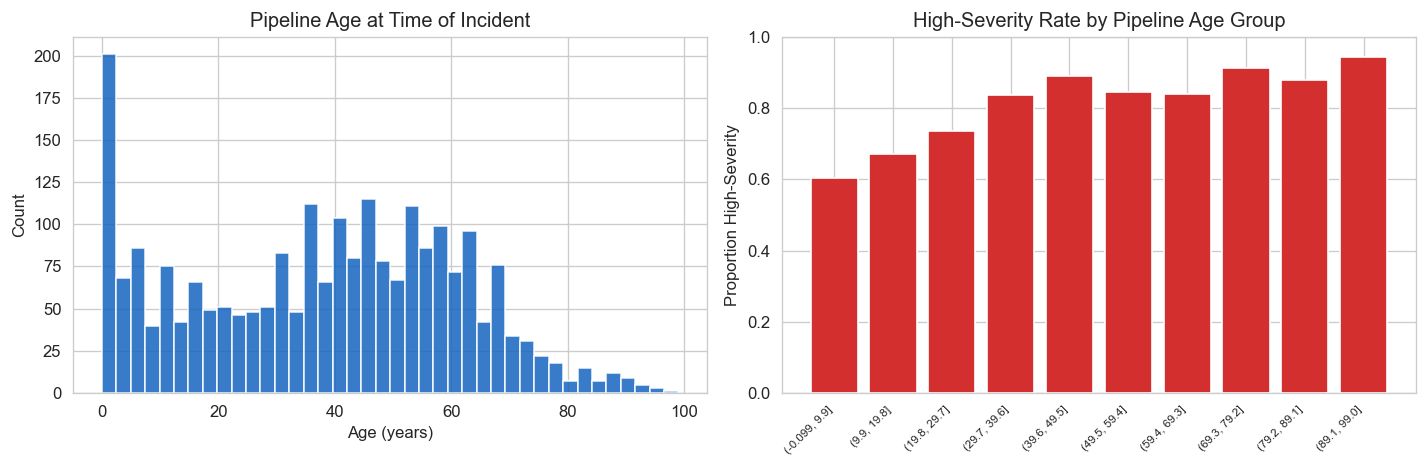

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Age distribution
ages = df['pipeline_age_at_incident'].dropna()
axes[0].hist(ages[ages < 100], bins=40, color='#1565C0', edgecolor='white', alpha=0.85)
axes[0].set_title('Pipeline Age at Time of Incident')
axes[0].set_xlabel('Age (years)')
axes[0].set_ylabel('Count')

# Age vs severity
age_sev = df.dropna(subset=['pipeline_age_at_incident'])
age_sev = age_sev[age_sev['pipeline_age_at_incident'] < 100]
age_bins = pd.cut(age_sev['pipeline_age_at_incident'], bins=10)
sev_rate = age_sev.groupby(age_bins)['high_severity'].mean()
axes[1].bar(range(len(sev_rate)), sev_rate.values, color='#D32F2F', edgecolor='white')
axes[1].set_xticks(range(len(sev_rate)))
axes[1].set_xticklabels([str(b) for b in sev_rate.index], rotation=45, ha='right', fontsize=7)
axes[1].set_title('High-Severity Rate by Pipeline Age Group')
axes[1].set_ylabel('Proportion High-Severity')
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.savefig(OUTPUTS / 'feature_temporal.png', bbox_inches='tight')
plt.show()

## 2. Pipeline Characteristic Features
- `pipe_diameter_numeric` — parsed from string to float (inches)
- `is_steel`, `is_cast_iron`, `is_plastic` — material type binary flags

Cast iron has the highest known failure risk due to brittleness and age.

In [5]:
df = add_pipeline_features(df)

material_sev = pd.DataFrame({
    'Material': ['Steel', 'Cast Iron', 'Plastic'],
    'Incidents': [df['is_steel'].sum(), df['is_cast_iron'].sum(), df['is_plastic'].sum()],
    'High Severity Rate': [
        df[df['is_steel'] == 1]['high_severity'].mean(),
        df[df['is_cast_iron'] == 1]['high_severity'].mean(),
        df[df['is_plastic'] == 1]['high_severity'].mean(),
    ]
})
print(material_sev.to_string(index=False))
print(f'\nDiameter range: {df["pipe_diameter_numeric"].min()} – {df["pipe_diameter_numeric"].max()} inches')

 Material  Incidents  High Severity Rate
    Steel       2015            0.741935
Cast Iron          0                 NaN
  Plastic        120            0.450000

Diameter range: 0.0 – 120.0 inches


## 3. Cause Encoding
The 6 canonical cause categories are one-hot encoded into binary features.

In [6]:
df = add_cause_features(df)
cause_cols = [c for c in df.columns if c.startswith('cause_')]
print('Cause feature columns:', cause_cols)
print(df[cause_cols].sum().to_string())

Cause feature columns: ['cause_corrosion', 'cause_excavation_damage', 'cause_natural_force', 'cause_equipment_failure', 'cause_incorrect_operation', 'cause_other']
cause_corrosion              563
cause_excavation_damage      493
cause_natural_force          248
cause_equipment_failure      754
cause_incorrect_operation    157
cause_other                  460


## 4. Spatial Features
- `county_incident_history` — how many incidents occurred in the same county
- `state_incident_rate` — % of national incidents in this state
- `is_high_density_state` — binary flag for top 10 incident states

In [7]:
df = add_spatial_features(df)
spatial_cols = ['county_incident_history', 'state_incident_rate', 'is_high_density_state']
print(df[spatial_cols].describe())

County shapefile found — running spatial join...


Spatial join complete.
       county_incident_history  state_incident_rate  is_high_density_state
count              2675.000000          2675.000000            2675.000000
mean                  3.810093             0.037383               0.625047
std                   3.889149             0.038944               0.484201
min                   0.000000             0.000144               0.000000
25%                   1.000000             0.007033               0.000000
50%                   3.000000             0.013779               1.000000
75%                   5.000000             0.099900               1.000000
max                  18.000000             0.099900               1.000000


## 5. Correlation Heatmap of Final Features

In [8]:
feature_df = select_features(df)
print(f'Final feature matrix: {feature_df.shape}')
print('Features:', feature_df.columns.tolist())

Dropping remaining object columns: ['REPORT_RECEIVED_DATE', 'REPORT_TYPE', 'NAME', 'OPERATOR_STREET_ADDRESS', 'OPERATOR_CITY_NAME', 'OPERATOR_STATE_ABBREVIATION', 'OPERATOR_POSTAL_CODE', 'LOCAL_DATETIME', 'TIME_ZONE', 'DAYLIGHT_SAVINGS_IND', 'NRC_RPT_NUM', 'NRC_RPT_DATETIME', 'ADDITIONAL_NRC_REPORT_NUMBERS', 'COMMODITY_RELEASED_TYPE', 'COMMODITY_DETAILS', 'FATALITY_IND', 'INJURY_IND', 'STATUS_WHEN_IDENTIFIED', 'SHUTDOWN_DUE_ACCIDENT_IND', 'SHUTDOWN_EXPLAIN', 'SHUTDOWN_DATETIME', 'RESTART_DATETIME', 'STILL_SHUTDOWN_IND', 'COMMUNICATION_STATE_FED_IND', 'PARTY_INITIATED_COMMUNICATION', 'INITIAL_RESPONDER_COM_DATETIME', 'IGNITE_IND', 'IGNITE_DATETIME', 'HOW_EXTINGUISHED', 'HOW_EXTINGUISHED_OTHER_DETAIL', 'EXPLODE_IND', 'UPSTREAM_ACTION_TAKEN', 'UPSTREAM_OPRTNL_CNTRL_DETAIL', 'UPSTREAM_VALVE_CLOSE_DATETIME', 'DOWNSTREAM_ACTION_TAKEN', 'DOWNSTREAM_OPRTNL_CNTRL_DETAIL', 'DOWNSTREAM_VLV_CLOSE_DATETIME', 'INCIDENT_IDENTIFIED_DATETIME', 'ON_SITE_DATETIME', 'CONFIRMED_DISCOVERY_DATETIME', 'ON_OFF

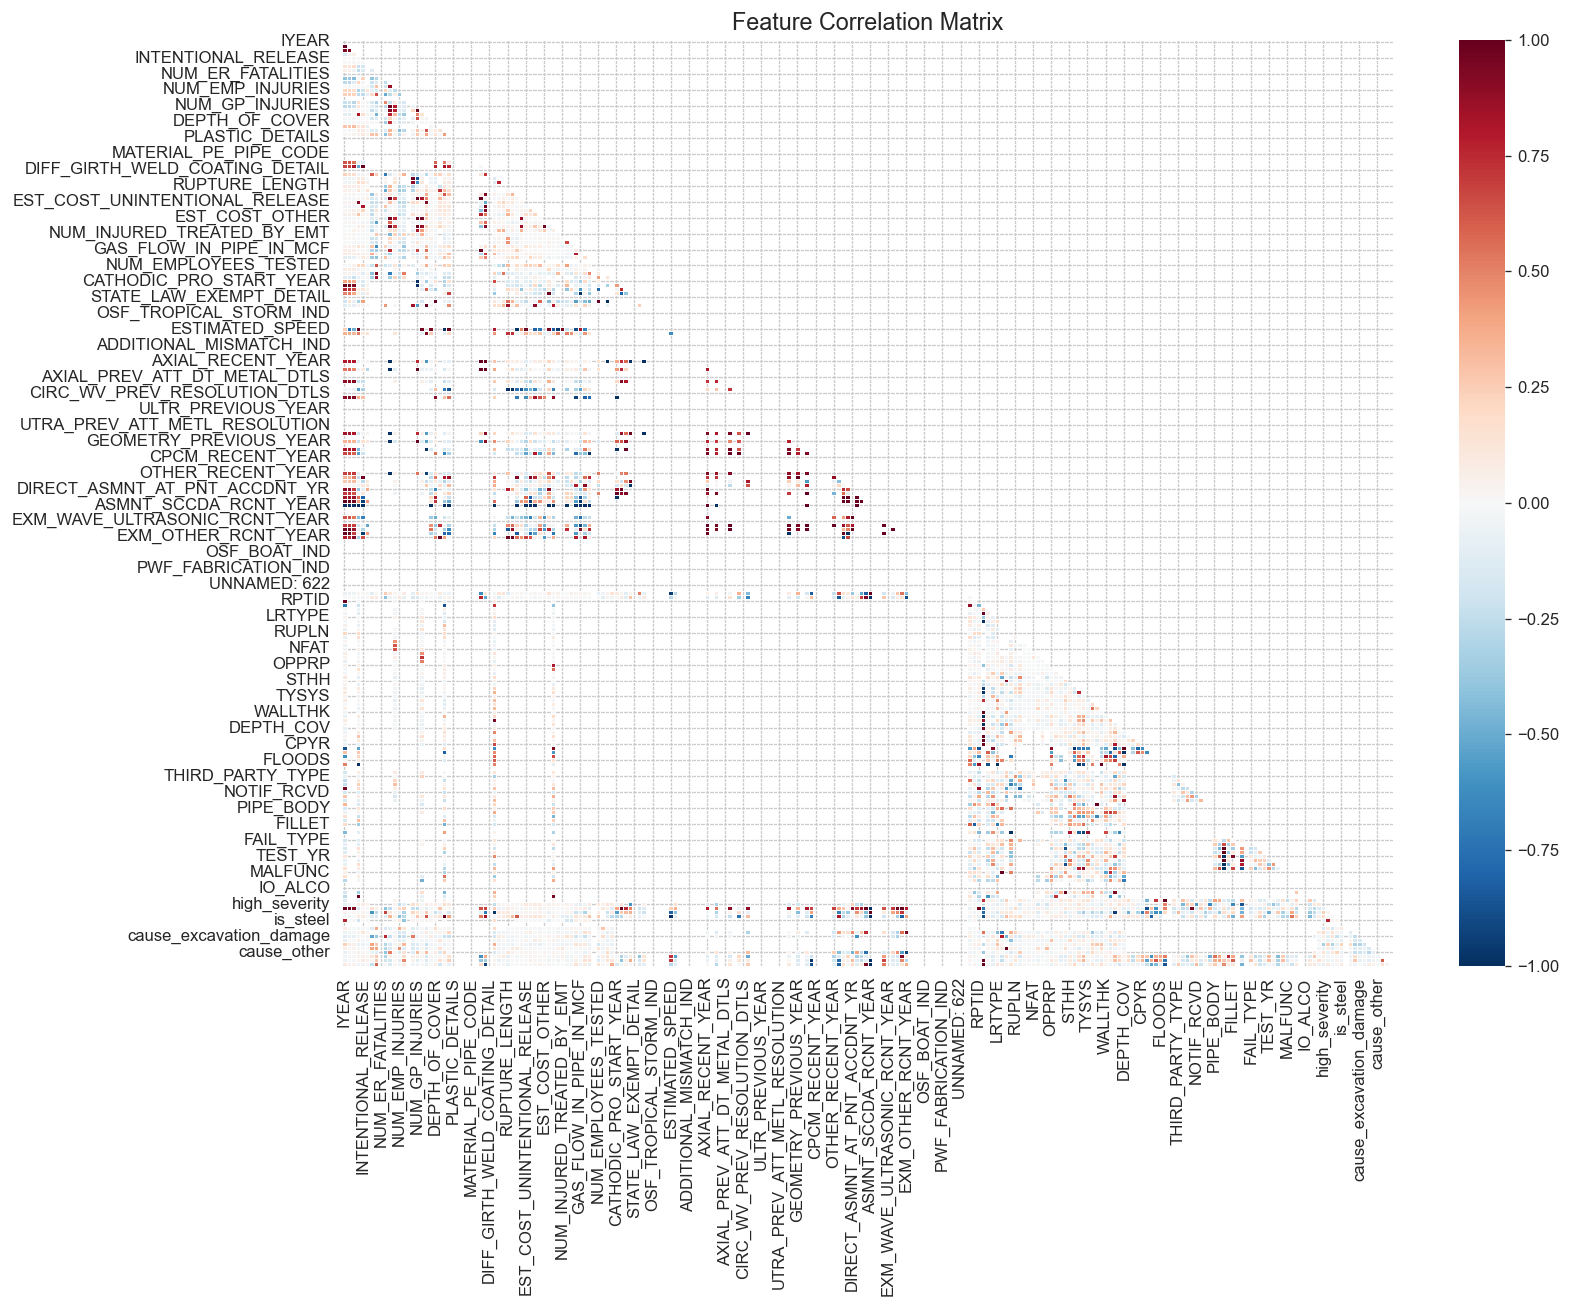

In [9]:
numeric_features = feature_df.select_dtypes(include=np.number)
corr = numeric_features.corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, cmap='RdBu_r', center=0,
    annot=len(corr) <= 20, fmt='.2f', linewidths=0.3,
    ax=ax, vmin=-1, vmax=1
)
ax.set_title('Feature Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.savefig(OUTPUTS / 'feature_correlation.png', bbox_inches='tight')
plt.show()

## 6. Feature–Target Correlation

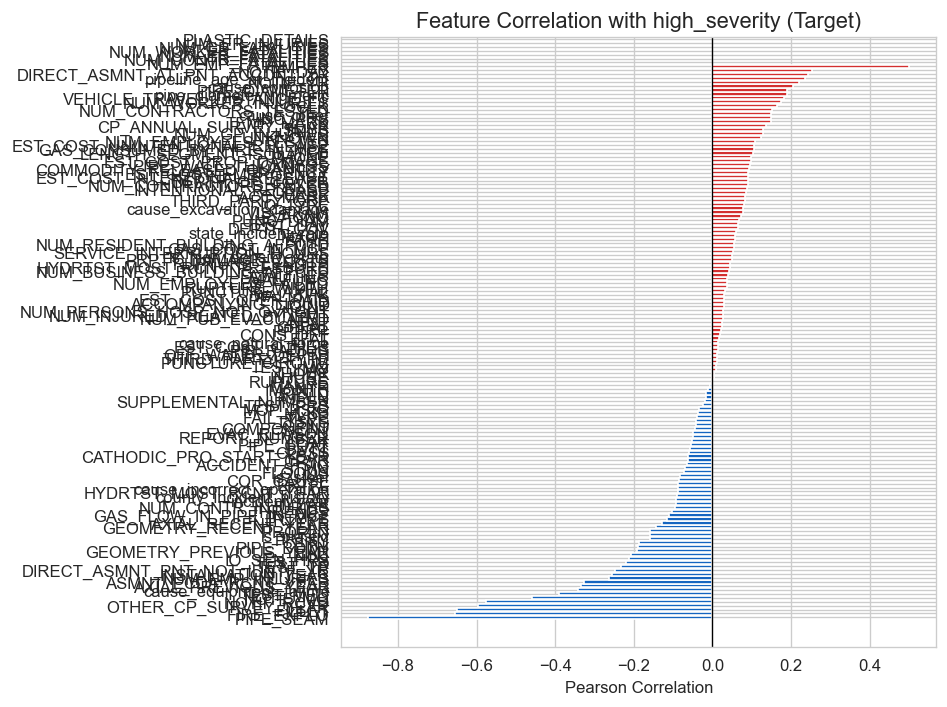

In [10]:
target_corr = numeric_features.corr()['high_severity'].drop('high_severity').sort_values()

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#D32F2F' if v > 0 else '#1565C0' for v in target_corr.values]
ax.barh(target_corr.index, target_corr.values, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Feature Correlation with high_severity (Target)', fontsize=13)
ax.set_xlabel('Pearson Correlation')
plt.tight_layout()
plt.savefig(OUTPUTS / 'feature_target_correlation.png', bbox_inches='tight')
plt.show()

## 7. Save Feature Matrix

In [11]:
out_path = PROCESSED / 'pipeline_features.csv'
feature_df.to_csv(out_path, index=False)
print(f'Feature matrix saved → {out_path}')
print(f'Shape: {feature_df.shape}')
print(f'Target balance:\n{feature_df["high_severity"].value_counts().to_string()}')

Feature matrix saved → ../data/processed/pipeline_features.csv
Shape: (2675, 232)
Target balance:
high_severity
1    2038
0     637
